In [93]:
using JLD2,Plots,LinearAlgebra


In [94]:
s1=load("0.8radius37.0num_points20.0uD10.0er3.0NL0.0tgden0.01temp-100.0JH10.0CNP1.5ildis2.0shift1.0trytime.jld2")

Dict{String, Any} with 20 entries:
  "eig_vec_set"            => Vector{Matrix{ComplexF64}}[[[0.141082+0.192083im …
  "energy"                 => -0.852507
  "eout"                   => 7.09165e-15
  "parent_energy"          => -0.700158
  "Hartree_matrix"         => ComplexF64[-4.48822+0.0im 0.0+0.0im … 0.0+0.0im 0…
  "parent_HF_eigenvalues"  => [-151.954 -146.429 … -146.062 -151.587; -151.221 …
  "renormalized_density"   => 0.0
  "parent_Hartree_matrix"  => ComplexF64[-5.21477+0.0im 0.0+0.0im … 0.0+0.0im 0…
  "eig_set"                => [[[-664.958, -460.994, -141.431, 179.828, 464.233…
  "fermi_level"            => -11.6941
  "single_matrix"          => ComplexF64[-141.431+0.0im 0.0+0.0im … 0.0+0.0im 0…
  "final_density_matrix"   => ComplexF64[-2.11592e-6+0.0im 0.0+0.0im … -1.72977…
  "parent_Fock_matrix"     => ComplexF64[-1.65339-3.72408e-18im 0.0+0.0im … 0.0…
  "k_index"                => [[1, 1], [1, 2], [1, 3], [1, 4], [1, 5], [1, 6], …
  "parent_HF_eigenvectors" => ComplexF64[

In [95]:
k_set=s1["k_set"]
k_index=s1["k_index"]
HF_eigenvalues=s1["HF_eigenvalues"]
parent_HF_eigenvalues=s1["parent_HF_eigenvalues"]
parent_Hartree_matrix=s1["parent_Hartree_matrix"]
single_matrix=s1["single_matrix"]
parent_Fock_matrix=s1["parent_Fock_matrix"]
parent_DS=s1["parent_DS"]
spin_num=2
layer_num=2
valley_num=2

parent_DS=reshape(parent_DS,spin_num,valley_num,layer_num,spin_num,valley_num,layer_num,length(k_set))

2×2×2×2×2×2×1369 Array{ComplexF64, 7}:
[:, :, 1, 1, 1, 1, 1] =
 -4.78548e-14+0.0im  -1.10502e-20-2.45581e-22im
          0.0+0.0im           0.0+0.0im

[:, :, 2, 1, 1, 1, 1] =
 0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im

[:, :, 1, 2, 1, 1, 1] =
         0.0+0.0im          0.0+0.0im
 5.51497e-18+0.0im  1.04063e-24+3.01386e-25im

[:, :, 2, 2, 1, 1, 1] =
 0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im

[:, :, 1, 1, 2, 1, 1] =
 -1.10502e-20+2.45581e-22im  -5.64173e-17+0.0im
          0.0+0.0im                   0.0+0.0im

[:, :, 2, 1, 2, 1, 1] =
 0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im

[:, :, 1, 2, 2, 1, 1] =
         0.0+0.0im                   0.0+0.0im
 1.04063e-24-3.01386e-25im  -1.63731e-17+0.0im

[:, :, 2, 2, 2, 1, 1] =
 0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im

[:, :, 1, 1, 1, 2, 1] =
 0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im

[:, :, 2, 1, 1, 2, 1] =
 4.7873e-14+0.0im  6.08533e-24+1.89437e-24im
        0.0+0.0im          0.0+0.0im

[:, :, 1, 2, 1, 2, 1] =
 0.0+0.0im  0.0+0.0im
 

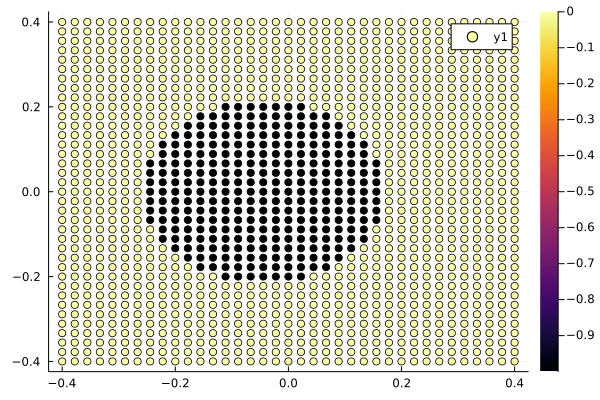

In [96]:
v1=[]
v2=[]
v3=[]

valley_z=zeros(ComplexF64,valley_num,valley_num)
valley_z=[1 0;0 -1]




for ja in eachindex(k_set)
  push!(v1,k_set[ja][1])
  push!(v2,k_set[ja][2])
  push!(v3,tr(valley_z*parent_DS[1,:,1,1,:,1,ja]))
end
scatter(v1,v2,zcolor=real(v3))

In [97]:
sum(abs.(parent_DS[:,:,1,:,:,2,:]))

0.0

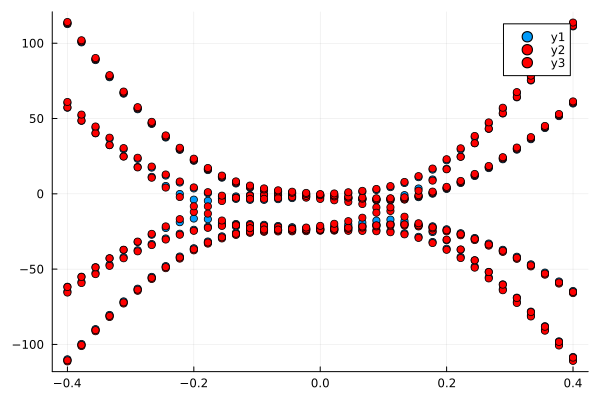

In [98]:

v1=[]
v2=[]
for ja in eachindex(k_set), jb in 1:8
    if k_index[ja][2]==12
      push!(v1,k_set[ja][1])
      push!(v2,HF_eigenvalues[jb,ja])
    end
  
end
scatter(v1,v2)

v1=[]
v2=[]
for ja in eachindex(k_set)
    if k_index[ja][2]==12
   
      ss=-parent_Fock_matrix[:,:,ja]+parent_Hartree_matrix[:,:,ja]+single_matrix[:,:,ja]
      ss=reshape(ss,spin_num*valley_num,layer_num,spin_num*valley_num,layer_num)
      FFF=eigen(ss[:,1,:,1])
      for jb in 1:4
           push!(v1,k_set[ja][1])
           push!(v2,real(FFF.values[jb]))
      end
    end
  
end
scatter!(v1,v2,color=:red)

v1=[]
v2=[]
for ja in eachindex(k_set)
    if k_index[ja][2]==12
   
      ss=-parent_Fock_matrix[:,:,ja]+parent_Hartree_matrix[:,:,ja]+single_matrix[:,:,ja]
      ss=reshape(ss,spin_num*valley_num,layer_num,spin_num*valley_num,layer_num)
      FFF=eigen(ss[:,2,:,2])
      for jb in 1:4
           push!(v1,k_set[ja][1])
           push!(v2,real(FFF.values[jb]))
      end
    end
  
end
scatter!(v1,v2,color=:red)

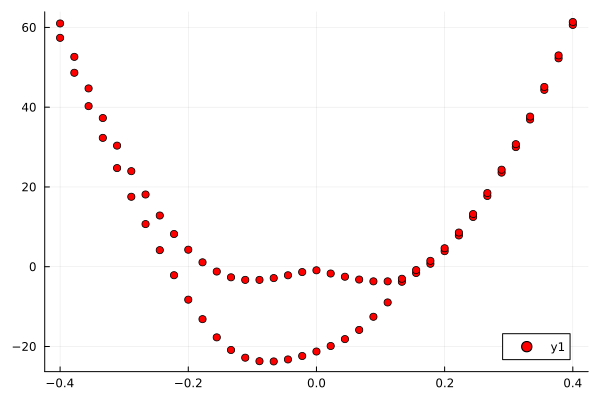

In [99]:
v1=[]
v2=[]
for ja in eachindex(k_set)
    if k_index[ja][2]==12
   
      ss=-parent_Fock_matrix[:,:,ja]+parent_Hartree_matrix[:,:,ja]+single_matrix[:,:,ja]
      ss=reshape(ss,spin_num*valley_num,layer_num,spin_num*valley_num,layer_num)
      FFF=eigen(ss[:,2,:,2])
      for jb in 1:2
           push!(v1,k_set[ja][1])
           push!(v2,real(FFF.values[jb]))
      end
    end
  
end
scatter(v1,v2,color=:red)